## The financial Agent

In [1]:
import asyncio

from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from src.financial_analysis_agent.agents.agents import (
    get_financial_agent,
    get_macro_agent,
    get_news_agent,
    get_recommendation_agent,
)
from src.financial_analysis_agent.config import llm
from src.financial_analysis_agent.logger import logger
from src.financial_analysis_agent.prompts.prompts import (
    router_prompt,
    summarizer_prompt,
)
from src.financial_analysis_agent.state.state import (
    AgentInput,
    ClassificationResult,
    RouterState,
)


async def normalize_input(state: RouterState, context=None) -> dict:
    thread_id = getattr(context, "thread_id", None) if context else None
    logger.info(f"Thread ID: {thread_id}")

    logger.debug("Entered normalize_input")
    messages = state.get("messages", [])
    logger.info(f"Received {len(messages)} messages")

    if messages:
        last_msg = messages[-1]
        user_input = (
            last_msg.content
            if hasattr(last_msg, "content")
            else last_msg.get("content", "")
        )
        logger.info(f"Extracted fresh query: {user_input}")

        return {"query": user_input, "results": []}
    return {}


async def classify_query(state: RouterState) -> dict:
    logger.debug("Entered classify_query")
    query = state.get("query")
    history = state.get("messages", [])[:-1]
    logger.info(f"Classify Query: Received query: {query}")
    logger.info(f"Classify Query: Received history: {history}")

    structured_llm = llm.with_structured_output(ClassificationResult)
    result = await structured_llm.ainvoke(
        [
            {"role": "system", "content": router_prompt()},
            *history,
            {"role": "user", "content": query},
        ]
    )

    logger.info(f"Classification result: {result.classifications}")
    return {"classifications": result.classifications}


async def route_to_agents(state: RouterState):
    """
    Fan out to agents. If no agents are classified, return the string 'summarize'
    to trigger the direct path to the aggregator/synthesizer.
    """
    classifications = state.get("classifications", [])

    if not classifications:
        logger.info("No agents matched. Routing directly to summarize (aggregator).")
        return "summarize"

    logger.info(f"Routing to agents: {[c['source'] for c in classifications]}")
    return [Send(c["source"], {"query": c["query"]}) for c in classifications]


async def query_financial_agent(state: AgentInput) -> dict:
    agent = await get_financial_agent()
    logger.info(f"Querying financial agent with query: {state['query']}")
    result = await agent.ainvoke(
        {"messages": [{"role": "user", "content": state["query"]}]}
    )
    return {
        "results": [
            {"source": "financial_agent", "result": result["messages"][-1].content}
        ]
    }


async def query_recomendation_agent(state: AgentInput) -> dict:
    agent = await get_recommendation_agent()
    logger.info(f"Querying recomendation agent with query: {state['query']}")
    result = await agent.ainvoke(
        {"messages": [{"role": "user", "content": state["query"]}]}
    )
    return {
        "results": [
            {"source": "recomendation_agent", "result": result["messages"][-1].content}
        ]
    }


async def query_news_agent(state: AgentInput) -> dict:
    agent = await get_news_agent()
    query = state.get("query")
    companies = [c.strip() for c in query.split(",")]
    logger.info(f"Querying news agent with companies: {companies}")

    async def fetch(company):
        result = await agent.ainvoke(
            {"messages": [{"role": "user", "content": company}]}
        )
        return {
            "source": "news_agent",
            "company": company,
            "result": result["messages"][-1].content,
        }

    results = await asyncio.gather(*(fetch(c) for c in companies))
    return {"results": [{"source": "news_agent", "result": results}]}


async def query_macro_agent(state: AgentInput) -> dict:
    agent = await get_macro_agent()
    logger.info(f"Querying macro agent with query: {state['query']}")
    result = await agent.ainvoke(
        {"messages": [{"role": "user", "content": state["query"]}]}
    )
    return {
        "results": [{"source": "macro_agent", "result": result["messages"][-1].content}]
    }


async def aggregator(state: RouterState):
    logger.info("Aggregating agent results")
    return {}


async def synthesizer(state: RouterState) -> dict:
    logger.debug("Entered synthesizer")

    results = state.get("results", [])

    if results:
        formatted = [f"**From {r['source'].title()}:**\n{r['result']}" for r in results]
        agent_context = "\n\nNew information retrieved:\n" + "\n\n".join(formatted)
    else:
        agent_context = "\n(No new external data was needed for this request.)"

    synthesis_response = await llm.ainvoke(
        [
            {"role": "system", "content": summarizer_prompt(state)},
            *state["messages"],
            {
                "role": "user",
                "content": f"Answer the user's latest request. {agent_context}",
            },
        ]
    )

    logger.info(f"Synthesis response: {synthesis_response}")

    return {
        "messages": [synthesis_response],
        # "final_answer": synthesis_response.content,
    }


agent_builder = StateGraph(RouterState)

agent_builder.add_node("normalize", normalize_input)
agent_builder.add_node("classify", classify_query)
agent_builder.add_node("financial_agent", query_financial_agent)
agent_builder.add_node("macro_agent", query_macro_agent)
agent_builder.add_node("news_agent", query_news_agent)
agent_builder.add_node("recomendation_agent", query_recomendation_agent)
agent_builder.add_node("synthesize", synthesizer)
agent_builder.add_node("aggregator", aggregator)

agent_builder.add_edge(START, "normalize")
agent_builder.add_edge("normalize", "classify")

agent_builder.add_conditional_edges(
    "classify",
    route_to_agents,
    {
        "financial_agent": "financial_agent",
        "news_agent": "news_agent",
        "recomendation_agent": "recomendation_agent",
        "macro_agent": "macro_agent",
        "summarize": "aggregator",
    },
)

agent_builder.add_edge("financial_agent", "aggregator")
agent_builder.add_edge("news_agent", "aggregator")
agent_builder.add_edge("recomendation_agent", "aggregator")
agent_builder.add_edge("macro_agent", "aggregator")
agent_builder.add_edge("aggregator", "synthesize")
agent_builder.add_edge("synthesize", END)

agent = agent_builder.compile()

[03/06/26 09:38:07] INFO     2026-03-06 09:38:07,781 - app_logger - INFO - Environment variables loaded via dotenv

                    INFO     2026-03-06 09:38:07,972 - app_logger - INFO - Dual-model architecture initialized:    
                             GPT-5-mini (Agent) | GPT-4o-mini (Router/Summary)

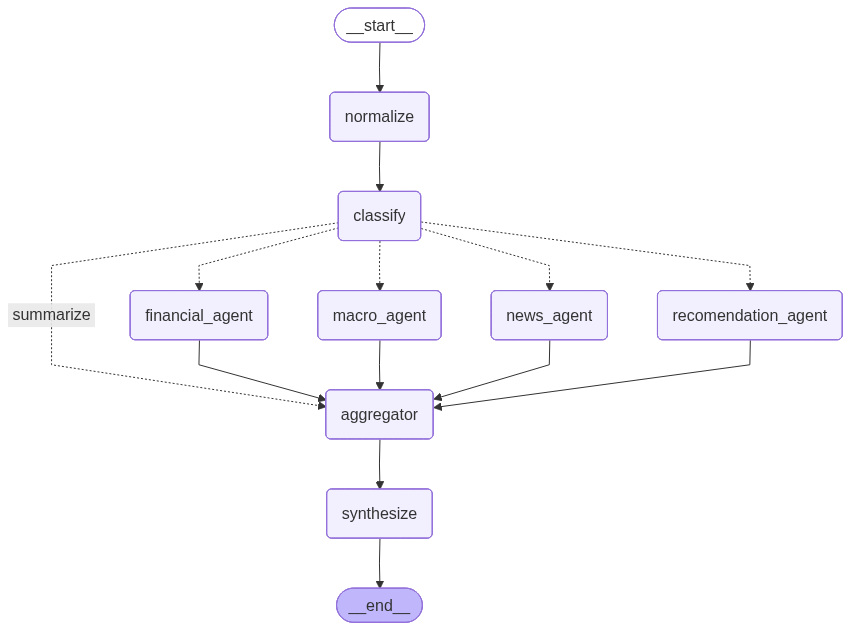

In [2]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [ ]:
# result = await agent.ainvoke({"query": "Get the last quarterly balance sheet for Microsoft"})

In [ ]:
# from rich import print

# print(result["final_answer"])